# Program - plot XY series in SCM and George's LES

**Content:**

- Open and Read SCM netCDF files
- Open and Read LES netCDF files
- Plot XY time series

**Author**: Yi-Hsuan Chen (yihsuan@umich.edu)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import io, os, sys, types
import yhc_module as yhc
import read_data_mac as read_data

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Read RF01 & RF02 SCM data

### SCM RF01 with am4 RAD + SW

In [2]:
choice = "SCM_RF01_00cf_am4RAD"
da_rf01_am4RAD_ICStv_FStv, da_rf01_am4RAD_ICStv_2Xdiv,  \
               da_rf01_am4RAD_ICStv_CGhadv, da_rf01_am4RAD_ICStv_FAM4n, \
               da_rf01_am4RAD_ICStv_FMRA, da_rf01_am4RAD_ICAM4n_FAM4n, \
               da_rf01_am4RAD_ICMRA_FMRA, \
               da_rf01_am4RAD_ICStv_L07div, da_rf01_am4RAD_ICStv_L07div_CGhadv = read_data.read_scm_data(choice)

In [3]:
#da_rf01_am4RAD_ICStv_FAM4n.swdn_toa[0:24]

### SCM RF01 with scm RAD

In [4]:
choice = "SCM_RF01_00cf_scmRAD"
da_rf01_scmRAD_ICStv_FStv, da_rf01_scmRAD_ICStv_2Xdiv, \
               da_rf01_scmRAD_ICStv_CGhadv, da_rf01_scmRAD_ICStv_FAM4n, \
               da_rf01_scmRAD_ICStv_FMRA, \
               da_rf01_scmRAD_ICStv_L07div, da_rf01_scmRAD_ICStv_L07div_CGhadv = read_data.read_scm_data(choice)

### SCM RF02 with am4 RAD + SW

In [5]:
choice = "SCM_RF02_00cf_am4RAD"
da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv,  \
               da_rf02_am4RAD_ICStv_CGhadv, da_rf02_am4RAD_ICStv_FAM4n, \
               da_rf02_am4RAD_ICStv_FMRA, da_rf02_am4RAD_ICAM4n_FAM4n, \
               da_rf02_am4RAD_ICMRA_FMRA, \
               da_rf02_am4RAD_ICStv_L07div, da_rf02_am4RAD_ICStv_L07div_CGhadv = read_data.read_scm_data(choice)

### SCM RF02 with scm RAD

In [6]:
choice = "SCM_RF02_00cf_scmRAD"
da_rf02_scmRAD_ICStv_FStv, da_rf02_scmRAD_ICStv_2Xdiv, \
               da_rf02_scmRAD_ICStv_CGhadv, da_rf02_scmRAD_ICStv_FAM4n, \
               da_rf02_scmRAD_ICStv_FMRA, \
               da_rf02_scmRAD_ICStv_L07div, da_rf02_scmRAD_ICStv_L07div_CGhadv = read_data.read_scm_data(choice)

### From data.scm.original, SCM RF01 & RF02

## Read RF01 & RF02 LES data


### RF01, George's LES

In [7]:
choice = "les_george_rf01"
da_les_stv, da_les_stv_2Xdiv, da_les_stv_4Xdiv, da_les_merra3D, da_les_merraIC_F = \
    read_data.read_les_data(choice)

### RF02, George's LES

In [8]:
choice = "les_george_rf02"
da_les_rf02 = \
    read_data.read_les_data(choice)

### Open RF01 LES intercomparison data

In [9]:
choice = "les_intercomp_rf01"

da_les_comp = \
    read_data.read_les_data(choice)

### Open RF02 LES intercomparison data

In [10]:
choice = "les_intercomp_rf02"

da_les_comp_rf02 = \
    read_data.read_les_data(choice)

dr=1
sed=1
varname1='lwp'
tt1=0
tt2=72

lwpmax_les_comp_rf02 = da_les_comp_rf02.get(varname1)[:,dr, sed, tt1:tt2].max(dim='group')
lwpmin_les_comp_rf02 = da_les_comp_rf02.get(varname1)[:,dr, sed, tt1:tt2].min(dim='group')
lwpmed_les_comp_rf02 = da_les_comp_rf02.get(varname1)[:,dr, sed, tt1:tt2].median(dim='group'),
lwpuquan_les_comp_rf02 = da_les_comp_rf02.get(varname1)[:,dr, sed, tt1:tt2].quantile(0.75, dim='group')
lwplquan_les_comp_rf02 = da_les_comp_rf02.get(varname1)[:,dr, sed, tt1:tt2].quantile(0.25, dim='group')
lwpavg_les_comp_rf02 = da_les_comp_rf02.get(varname1)[:,dr, sed, tt1:tt2].mean(dim='group')
tt_les_comp_rf02 = np.arange(0, tt2*300, 300)

#tt3 = 60
#dr=0; sed=0
#yhc.printv(da_les_comp_rf02.get(varname1)[:,dr, sed, tt3:tt2].mean(dim='group'), 'dr0, sed0','r')

#dr=1; sed=1
#yhc.printv(da_les_comp_rf02.get(varname1)[:,dr, sed, tt3:tt2].mean(dim='group'), 'dr1, sed1','g')

#print(da_les_comp_rf02.get(varname1)[:,dr, sed, tt3].min(dim='group'))
#print(da_les_comp_rf02.get(varname1)[:,dr, sed, tt3])

### RF01 data in Matheou and Teixeira (2019, MWR)

### Check LES data

## Define plotting functions

### Set time coordinate

In [11]:
#--- set time coordinate
time_coord = "hours"

if (time_coord == "hours"):
    ntime = len(da_rf01_am4RAD_ICStv_FStv.time)
    tt = np.linspace(0., (ntime-1)/2., ntime)   # SCM time step is 30 minutes
    
else:
    err_msg = f"ERROR: time coord [{time_coord}] is not supported"
    raise ValueError(err_msg)

#print(tt)
#print(tt.min())

#### set time labels

In [12]:
def set_time_ticks(ax, iop):
    
    #--- set time tick values
    tt_values = np.arange(0,13,2)
    #tt_values = np.linespace()
    #print(tt_values)

    #tt_labels = np.array2string (np.arange(8,21,2))
    #print(tt_labels)
    #print(len(tt_labels))

    #tt_values = np.array([0,4,8,12,16,20]) 
    tt_labels = ["08", "10", "12", "14", "16", "18", "20"]

    if (iop == "RF01"):
        tt_labels[0] = "08 \n (July 10)"
    elif (iop == "RF02"):
        tt_labels[0] = "08 \n (July 11)"
    
    print(tt_values)
    print(tt_labels)

    #--- set time coordinate
    ax.set_xlabel("UTC Time (hour)")
    ax.set_xticks(tt_values)
    ax.set_xticklabels(tt_labels)
    
    #ax.xaxis.set_minor_locator(MultipleLocator(1))
    
#-----------
# do_test
#-----------

#do_test=True
do_test=False

pp = list(da_rf02_am4RAD_ICStv_FStv.keys())
#print(pp)

if (do_test):
    fig, ax1 = plt.subplots(1,1, figsize=(25, 10))

    names_styles = {
        "da1": "r--",
        "da2": "b--",
        "da3": "g--",
    }
    
    varname = "LWP"
    tt_start = 0
    tt_end = 10
                    
    plot_scm_time_series(da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, da_rf02_scmRAD_ICStv_FAM4n, 
                         time_coord=tt, 
                         tt_start = tt_start, tt_end = tt_end, 
                         names_styles = names_styles, varname = varname, ax=ax1, var_factor = 1000)
    
    set_time_ticks(ax1, "RF01")

In [13]:
def check_var_in_da (da, varname): 
    
    """
    ----------------------
    Description:


    Input arguments:


    Return:


    Example:
      import yhc_module as yhc
       = yhc.()

    Date created: 2023-01-08
    ----------------------
    """

    func_name = "check_var_in_da"

    #--- get all variable names in the dataset
    allvars = list(da.keys())  

    #--- check whether the da has varname
    if (varname not in allvars):
        error_msg = f"ERROR: function [{func_name}], the input dataset does not have variable [{varname}]"
        raise ValueError(error_msg)

    return
    
#-----------
# do_test
#-----------

#do_test=True
do_test=False

if (do_test):
    varname = "LWP1"
    check_var_in_da (da_rf02_am4RAD_ICStv_FStv, varname)


#### Set default parameters

In [14]:
#--- set default values for font group  
font_default = {
    'size': 20,      # font size 
       }
plt.rc('font', **font_default)

       
#--- set default values for lines group  
lines_default = {
    'linewidth':5,
}
plt.rc('lines', **lines_default)

#### plot_scm_time_series

In [29]:
def plot_scm_time_series(datasets, time_coord, 
                         ax, names_styles, varname, 
                         do_unit_convert = False, var_factor = 1, 
                         do_var_stats = True, tt_start = "none", tt_end = "none", 
                         plot_les = "none", 
                        ):
    
    func_name = "plot_scm_time_series"
    
    #------------------------
    # set shared parameters
    #------------------------
    legend_size = 16
    
    #--------------
    # check parts
    #--------------
    
    #--- make sure # of dataset is not greater than # of names_styles
    nda = len(datasets)        # number of dataset
    nname = len(names_styles) # number of names
    
    if (nda > nname):
        error_msg = f"ERROR: function [{func_name}], # of dataset [{nda}] > # of names_styles [{nname}]"
        raise ValueError(error_msg)
      
    #--------------------------------------
    # plot
    #--------------------------------------
    
    #--- get names of all datasets
    da_names = list(names_styles.keys())  
    
    #--- loop for all datesets
    i=0
    for da1 in datasets:

        #--------------------------------------
        # plot the variable in each dataset
        #--------------------------------------
        
        #--- get dataset custom name and color style
        name1 = da_names[i]
        style1 = names_styles[name1]
        
        #--- check whether da1 has varname
        check_var_in_da(da1, varname)
        
        #--- read variable
        var1 = da1.get(varname)[:,0,0]
        if (do_unit_convert): 
            var1 = yhc.unit_convert(var1)   # change units if needed
        else:
            var1 = var1.copy()*var_factor
            if (var_factor == 1):
                unit1 = var1.attrs['units']
            else:
                unit1 = var1.attrs['units']+" / "+str(var_factor)
        
        #--- set time coordinate
        #ntime = len(da1.time)
        #tt = np.arange(0., ntime, 1)
        tt = time_coord
        
        #--- plot the time series
        ax.plot(tt, var1, style1) 

        #--- set labels
        ax.set_title(varname, loc='left')
        ax.set_title(unit1, loc='right')
        ax.set_xlabel("Hours")
        ylabel = var1.attrs['long_name']+" ("+unit1+")"
        ax.set_ylabel(ylabel)
        
        #--- plot legend
        ax.legend(da_names, prop={'size': legend_size})

        #--------------------------------------
        # do some statistics of the variables
        #--------------------------------------
        
        if (do_var_stats):
        
            #--- get time range
            if (tt_start != "none" and tt_end != "none"):
                tt1 = tt_start
                tt2 = tt_end
            else:
                tt1 = 0
                tt2 = len(var1)
                
            #--- print time coordinates
            if (i==0): print(var1.time[tt1:tt2])

            var1_avg = var1[tt1:tt2].mean("time")
            var1_avg_str = '{:.1f}'.format(np.array(var1_avg))

            string= f"Exp [{name1}], avg [{varname}] over time step [{tt1}, {tt2}] = {var1_avg_str}"
            #print("")
            print(string)

        #----------------------------- 
        # loop for another dataset
        #-----------------------------
        #print(i)
        i=i+1
        
    #-----------------
    #  George's LES 
    #-----------------
        
    s2hr = 1./3600.
    varname1_les = "lwp"
        
    #--- George's LES
    line_style = "--"
    style_1xDiv = style_ICStv_1Xdiv+line_style
    style_2xDiv = style_ICStv_2Xdiv+line_style
    style_FMRA = style_ICStv_FMRA+line_style
    style_IC_FMRA = style_IC_F_MRA+line_style
                
    if (plot_les == "George_RF01"):
        
        les_names = ["LES, 1xDiv",
                     "LES, 2XDiv",
                     "LES, Forc_MERRA",
                     "LES, MERRA IC & Forc"]
        ax.plot(
            da_les_stv.time[:]*s2hr, da_les_stv.get(varname1_les), style_1xDiv, 
            da_les_stv_2Xdiv.time[:]*s2hr, da_les_stv_2Xdiv.get(varname1_les), style_2xDiv,
            da_les_merra3D.time[:]*s2hr, da_les_merra3D.get(varname1_les), style_FMRA,
            da_les_merraIC_F.time[:]*s2hr, da_les_merraIC_F.get(varname1_les), style_IC_FMRA,
                )
        
        legend_labels = da_names+les_names
        ax.legend(legend_labels, prop={'size': legend_size})

        
    elif (plot_les == "George_RF01_1x2xDiv"):
        
        style_1xDiv = "m--"
        style_2xDiv = "c--"
        
        les_names = ["UConn LES, ORIG",
                     "UConn LES, 2xDIV",
                    ]
        #les_names = ["UConn LES, std forc",
        #             "UConn LES, 2XDiv",
        #            ]
                     #"LES, Forc_MERRA",
                     #"LES, MERRA IC & Forc"]
        ax.plot(
            da_les_stv.time[:]*s2hr, da_les_stv.get(varname1_les), style_1xDiv, 
            da_les_stv_2Xdiv.time[:]*s2hr, da_les_stv_2Xdiv.get(varname1_les), style_2xDiv,
            #da_les_merra3D.time[:]*s2hr, da_les_merra3D.get(varname1_les), style_FMRA,
            #da_les_merraIC_F.time[:]*s2hr, da_les_merraIC_F.get(varname1_les), style_IC_FMRA,
                )
        
        legend_labels = da_names+les_names
        ax.legend(legend_labels, prop={'size': legend_size})

    elif (plot_les == "George_RF02"):

        style_1xDiv = "m--"
        style_2xDiv = "c--"
        
        les_names = ["UConn LES, ORIG",
                     "UConn LES, 2xDIV",
                    ]

        ax.plot(
            da_les_rf02.time[:]*s2hr, da_les_rf02.get(varname1_les), style_1xDiv, 
               )
        legend_labels = da_names+les_names
        ax.legend(legend_labels, prop={'size': legend_size})

            
    #---------------
    # plot legend
    #---------------
    #legend_size = 16
    #ax.legend(da_names, prop={'size': legend_size})            

            
#-----------
# do_test
#-----------

#ppp=[da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, da_rf02_scmRAD_ICStv_FAM4n]
#print(ppp[0])

#for pp1 in ppp:
#    print(pp1)

#do_test=True
do_test=False

#pp = list(da_rf02_am4RAD_ICStv_FStv.keys())
#print(pp)

if (do_test):
    fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
    
    names_styles = {
        "da1": "r--",
        "da2": "b--",
        "da3": "g--",
        "da4": "m--",
    }
    
    varname = "LWP"
    tt_start = 0
    tt_end = 10
                    
    das = [da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, da_rf02_scmRAD_ICStv_FAM4n, da_rf02_am4RAD_ICStv_L07div]
    #plot_scm_time_series( das
    #                     da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, da_rf02_scmRAD_ICStv_FAM4n, 
    #plot_scm_time_series( [da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, da_rf02_scmRAD_ICStv_FAM4n],
    plot_scm_time_series( das, 
                         time_coord=tt, 
                         tt_start = tt_start, tt_end = tt_end, 
                         plot_les = "George_RF02",
                         names_styles = names_styles, varname = varname, ax=ax1, var_factor = 1000)
    

#### plot_les_obs

In [16]:
#da_les_stv, da_les_stv_2Xdiv, da_les_stv_4Xdiv, da_les_merra3D, da_les_merraIC_F

#da_les_stv_2Xdiv.time

#yhc.lib('pltxy')
#da_les_rf02.time/3600.


In [17]:
def plot_les_obs(ax, 
                 iop="none", plot_sunrise=False):

    s2hr = 1./3600.
    varname1_les = "lwp"
        
    #--- George's LES
    style_1xDiv = 'y-.'
    style_2xDiv = 'm-.'
    style_FMRA = 'b-.'
    style_IC_FMRA = 'c-.'

    #@@@@@@@@@@@@@@@@@@@@@@@@
    #@@@@@@@@@@@@@@@@@@@@@@@@
    if (iop == "RF01"):
        
        #------------
        # plot LES
        #-------------
        
        #--- George's LES 
        #ax.plot(
        #    da_les_stv.time[:]*s2hr, da_les_stv.get(varname1_les), style_1xDiv, 
        #    da_les_stv_2Xdiv.time[:]*s2hr, da_les_stv_2Xdiv.get(varname1_les), style_2xDiv,
        #    da_les_merra3D.time[:]*s2hr, da_les_merra3D.get(varname1_les), style_FMRA,
        #    da_les_merraIC_F.time[:]*s2hr, da_les_merraIC_F.get(varname1_les), style_IC_FMRA,
        #)
        
        #--- LES intercomparison
        factor_les_comp = 3600. 

        ax.plot(
            da_les_comp.time[:]/factor_les_comp, da_les_comp.lwp_bar[0,:], 'k-', 
               )
        #ax.text(4.2, 33, 'LES intercomparison', fontsize = 25)
        ax.text(3.8, 38, 'LES intercomparison', fontsize = 25)


        #--- plot color fill of min/max
        ax.fill_between( 
            da_les_comp.time[:]/factor_les_comp, da_les_comp.lwp_bar[2,:], da_les_comp.lwp_bar[3,:],color='gray', alpha=0.2,
                )

        #--- plot color fill of 1st/3rd qrtl 
        ax.fill_between( 
            da_les_comp.time[:]/factor_les_comp, da_les_comp.lwp_bar[4,:], da_les_comp.lwp_bar[5,:],color='gray', alpha=0.3,
                )
        
        #-----------
        # plot OBS
        #-----------
        lwp_OBS = 75.4 # Stevens et al. (2007)
        ax1.plot(
              [0.,4.],[lwp_OBS,lwp_OBS], 'k:',
                )
        #ax1.text(4.2, lwp_OBS-1.5, 'OBS', fontsize = 25)
        ax1.text(4.05, lwp_OBS-1.5, 'OBS', fontsize = 25)
 
    #@@@@@@@@@@@@@@@@@@@@@@@@
    #@@@@@@@@@@@@@@@@@@@@@@@@
    elif (iop == "RF02"):
        #------------
        # plot LES
        #-------------
        
        #--- George's LES 
        #ax.plot(
        #    da_les_rf02.time[:]*s2hr, da_les_rf02.get(varname1_les), style_1xDiv, 
        #)
        
        #--- LES intercomparison
        factor_les_comp = 3600. 

        ax.plot(
        tt_les_comp_rf02/factor_les_comp, lwpavg_les_comp_rf02, 'k-', 
        )
        
        #ax.text(6, 120, 'LES intercomparison', fontsize = 25)
        #ax.text(4, 120, 'LES intercomparison', fontsize = 25)
        ax.text(3.8, 110, 'LES intercomparison', fontsize = 25)

        #--- plot color fill of min/max
        ax.fill_between( 
            tt_les_comp_rf02/factor_les_comp, lwpmin_les_comp_rf02, lwpmax_les_comp_rf02,color='gray', alpha=0.2,
                )

        #--- plot color fill of 1st/3rd qrtl 
        ax.fill_between( 
            tt_les_comp_rf02/factor_les_comp, lwplquan_les_comp_rf02, lwpuquan_les_comp_rf02,color='gray', alpha=0.3,
                )

        #-----------
        # plot OBS
        #-----------
        lwp_OBS = 137.4 # Stevens et al. (2007)
        
        ax.plot(
              [0.,4.],[lwp_OBS,lwp_OBS], 'k:',
                )
        #ax.text(4.2, lwp_OBS-1.5, 'OBS', fontsize = 25)
        ax.text(4.05, lwp_OBS-1.5, 'OBS', fontsize = 25)

        
    #@@@@@@@@@@@@@@@@@@@@@@@@
    #@@@@@@@@@@@@@@@@@@@@@@@@
    #--- indicate sunrise time
    if (plot_sunrise):
        yy_sunrise = 0
        xx_sunrise = 6
        plt.annotate('Sunrise', xy=(xx_sunrise, yy_sunrise), xytext=(xx_sunrise, yy_sunrise+15),
                 arrowprops=dict(facecolor='black', shrink=0.01), fontsize = 15
                 )
            
#-----------
# do_test
#-----------

#do_test=True
do_test=False

if (do_test):
    fig, ax1 = plt.subplots(1,1, figsize=(25, 10)) 
    
    plot_les_obs(ax1, iop = "RF01")
    
    

#### compute_avg

In [18]:
def compute_avg(*datasets,
                names_styles, varname, tt1, tt2, 
                do_unit_convert = False, var_factor = 1, 
                model = "SCM", 
                        ):
    
    func_name = "compute_avg"
    
    #--------------
    # check parts
    #--------------
    
    #--- make sure # of dataset is not greater than # of names_styles
    nda = len(datasets)        # number of dataset
    nname = len(names_styles) # number of names
    
    if (nda > nname):
        error_msg = f"ERROR: function [{func_name}], # of dataset [{nda}] > # of names_styles [{nname}]"
        raise ValueError(error_msg)
      
    #--------------------------------------
    # plot the variable in each dataset
    #--------------------------------------
    
    #--- get names of all datasets
    da_names = list(names_styles.keys())  
    
    i=0
    for da1 in datasets:
        #--- get dataset custom name and color style
        name1 = da_names[i]
        style1 = names_styles[name1]
        
        #--- check whether da1 has varname
        check_var_in_da(da1, varname)
        
        #--- read variable
        if (model == "SCM"):
            var1 = da1.get(varname)[tt1:tt2,0,0].mean("time")
        elif (model == "LES"):
            var1 = da1.get(varname)[tt1:tt2].mean("time")
        
        if (do_unit_convert): 
            var1 = yhc.unit_convert(var1)   # change units if needed
        else:
            var1 = var1.copy()*var_factor
            if (var_factor == 1):
                unit1 = var1.attrs['units']
            else:
                unit1 = var1.attrs['units']+" / "+str(var_factor)
        
        var1_avg = '{:.1f}'.format(np.array(var1))
        
        string= f"exp=[{name1}], {varname} = {var1_avg}, [tt1,tt2]=[{tt1}, {tt2}]"
        #string= f"{name1}, {varname}"
        print(string)

        i=i+1

#-----------
# do_test
#-----------

#do_test=True
do_test=False

pp = list(da_rf02_am4RAD_ICStv_FStv.keys())
#print(pp)

if (do_test):
    #fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
    
    names_styles = {
        "da1": "r--",
        "da2": "b--",
        "da3": "g--",
    }
    
    tt1 = 4   # 3h
    tt2 = 8   # 4h
    
    varname = "LWP0"
                    
    compute_avg(da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, da_rf02_scmRAD_ICStv_FAM4n, 
                tt1=tt1, tt2=tt2, 
                names_styles = names_styles, varname = varname, var_factor = 1000)

#### ax_def_xy

In [19]:
#--- set shared feature

def ax_def_xy (ax, var):
    #--- set grids
    ax.grid(True)
    #ax.grid(which='major', color='gray', linewidth=0.7)
    #ax.grid(which='minor', color='gray', linewidth=0.7)
    #ax.xaxis.grid(which="minor", color='gray', linestyle='-.', linewidth=0.7)
    #ax.xaxis.grid(which="major", color='gray', linestyle='-.', linewidth=0.7)
    ax.minorticks_on()
    
    #--- legend
    #ax.legend(["SCM"])
    
    #--- set x or y labels
    fontsize_label = 30
    ax.set_xlabel("Time ("+time_coord+")", fontsize = fontsize_label)
    ax.set_ylabel(var.attrs['long_name']+" ("+var.attrs['units']+")", fontsize = fontsize_label)

    #--- set title
    fontsize_title = fontsize_label
    ax.set_title(var.attrs['long_name'], loc='left', fontsize = fontsize_title)
    ax.set_title(var.attrs['units'], loc='right', fontsize = fontsize_title)
    #ax.set_title("RF01", loc='center', fontsize = fontsize_title+10)
    
    #--- set x range
    #ax.set_xlim([tt.min(),tt.max()])
    #ax.set_xlim([tt.min(),35.])
    #ax.set_xlim([tt.min(),12])
    ax.set_xlim([tt.min(),5])
    #ax.set_xlim([tt.min(),20.])
    ax.set_ylim([0., 150.])
    
    #--- set tick mark sizes
    fontsize_tm = fontsize_label # set tick mark size
    ax.tick_params(axis='x', labelsize = fontsize_tm)
    ax.tick_params(axis='y', labelsize = fontsize_tm)
    

### Set dataset names & line styles

In [30]:
#--- dataset name
#da_option = "all"
#da_option = "subgroup_01"
da_option = "ICStv_Forc_Stv_L07_2rad"
#da_option = "RF01_02_orig"

#tavg_option = "3_4h"
tavg_option = "0_4h"

#--- variable name
varname = "LWP0"

#--- return time average
if (tavg_option == "3_4h"):
    tt_start = 4   # 3h
    tt_end = 8   # 4h

elif (tavg_option == "0_4h"):
    tt_start = 0   # 3h
    tt_end = 8     # 4h

elif (tavg_option == "1st_step"):
    tt_start=0
    tt_end=1

else:
    error_msg = f"ERROR: tavg_option [{tavg_option}] is not supported"
    raise ValueError(error_msg)
    
    
#--- all datasets
style_ICStv_1Xdiv = 'y'
style_ICStv_2Xdiv = 'm'
style_ICStv_1Xdiv_CGhadv = 'y:'
style_ICStv_FAM4n = "r"
style_ICStv_FMRA = "b"
style_ICStv_L07div = "c"
style_ICStv_L07div_CGhadv = "c:"
style_IC_F_AM4n = "r"
style_IC_F_MRA = "b"

if (da_option == "all"):

    names_styles_scmRAD = {
    "Stv IC, 1xDiv": style_ICStv_1Xdiv,
    "Stv IC, 2XDiv": style_ICStv_2Xdiv,
    "Stv IC, 1xDiv+hadv": style_ICStv_1Xdiv_CGhadv,
    "Stv IC, L07Div": style_ICStv_L07div,
    "Stv IC, L07Div+hadv": style_ICStv_L07div_CGhadv,
    "Stv IC, Forc_nudge_AM4": style_ICStv_FAM4n,
    "Stv IC, Forc_MERRA": style_ICStv_FMRA,
    }
    datasets_scmRAD_RF01 = [da_rf01_scmRAD_ICStv_FStv, da_rf01_scmRAD_ICStv_2Xdiv, 
                            da_rf01_scmRAD_ICStv_CGhadv, 
                            da_rf01_scmRAD_ICStv_L07div, da_rf01_scmRAD_ICStv_L07div_CGhadv,
                            da_rf01_scmRAD_ICStv_FAM4n, da_rf01_scmRAD_ICStv_FMRA] 

    datasets_scmRAD_RF02 = [da_rf02_scmRAD_ICStv_FStv, da_rf02_scmRAD_ICStv_2Xdiv, 
                            da_rf02_scmRAD_ICStv_CGhadv, 
                            da_rf02_scmRAD_ICStv_L07div, da_rf02_scmRAD_ICStv_L07div_CGhadv,
                            da_rf02_scmRAD_ICStv_FAM4n, da_rf02_scmRAD_ICStv_FMRA,] 

    names_styles_am4RAD = {
    "Stv IC, 1xDiv": style_ICStv_1Xdiv,
    "Stv IC, 2XDiv": style_ICStv_2Xdiv,
    "Stv IC, 1xDiv+hadv": style_ICStv_1Xdiv_CGhadv,
    "Stv IC, L07Div": style_ICStv_L07div,
    "Stv IC, L07Div+hadv": style_ICStv_L07div_CGhadv,
    "Stv IC, Forc_nudge_AM4": style_ICStv_FAM4n,
    "Stv IC, Forc_MERRA": style_ICStv_FMRA,
    "AM4 IC, Forc_nudge_AM4": style_IC_F_AM4n,
    "MERRA IC, Forc_MERRA": style_IC_F_MRA,
    }
    
    datasets_am4RAD_RF01 = [da_rf01_am4RAD_ICStv_FStv, da_rf01_am4RAD_ICStv_2Xdiv,  
    da_rf01_am4RAD_ICStv_CGhadv, 
    da_rf01_am4RAD_ICStv_L07div, da_rf01_am4RAD_ICStv_L07div_CGhadv, 
    da_rf01_am4RAD_ICStv_FAM4n, da_rf01_am4RAD_ICStv_FMRA, 
    da_rf01_am4RAD_ICAM4n_FAM4n, da_rf01_am4RAD_ICMRA_FMRA,
    ]

    datasets_am4RAD_RF02 = [da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv, 
                            da_rf02_am4RAD_ICStv_CGhadv, 
                            da_rf02_am4RAD_ICStv_L07div, da_rf02_am4RAD_ICStv_L07div_CGhadv, 
                            da_rf02_am4RAD_ICStv_FAM4n, da_rf02_am4RAD_ICStv_FMRA, 
                            da_rf02_am4RAD_ICAM4n_FAM4n, da_rf02_am4RAD_ICMRA_FMRA,
                           ]
    
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
elif (da_option == "subgroup_01"):

    style_ICStv_L07div_CGhadv = 'r-'
    style_ICStv_FMRA = "b"
    style_IC_F_MRA = "c"
    style_ICStv_FAM4n = "y"
    style_IC_F_AM4n = "pink"

    
    names_styles_scmRAD = {
    "Stv IC, 1xDiv": style_ICStv_1Xdiv,
    "Stv IC, L07Div+hadv": style_ICStv_L07div_CGhadv,
    "Stv IC, Forc_MERRA": style_ICStv_FMRA,
    }    
    
    datasets_scmRAD_RF01 = [da_rf01_scmRAD_ICStv_FStv, 
                            da_rf01_scmRAD_ICStv_L07div_CGhadv,
                            da_rf01_scmRAD_ICStv_FMRA] 

    datasets_scmRAD_RF02 = [da_rf02_scmRAD_ICStv_FStv, 
                            da_rf02_scmRAD_ICStv_L07div_CGhadv,
                            da_rf02_scmRAD_ICStv_FMRA,] 
    
    names_styles_am4RAD = {
    "Stv IC, 1xDiv": style_ICStv_1Xdiv,
    "Stv IC, L07Div+hadv": style_ICStv_L07div_CGhadv,
    "Stv IC, Forc_MERRA": style_ICStv_FMRA,
    "MERRA IC, Forc_MERRA": style_IC_F_MRA,
    "AM4 IC, Forc_nudge_AM4": style_IC_F_AM4n,
    }    

    datasets_am4RAD_RF01 = [da_rf01_am4RAD_ICStv_FStv, 
                            da_rf01_am4RAD_ICStv_L07div_CGhadv, 
                            da_rf01_am4RAD_ICStv_FMRA, da_rf01_am4RAD_ICMRA_FMRA,
                            da_rf01_am4RAD_ICAM4n_FAM4n,
                           ]

    datasets_am4RAD_RF02 = [da_rf02_am4RAD_ICStv_FStv, 
                            da_rf02_am4RAD_ICStv_L07div_CGhadv, 
                            da_rf02_am4RAD_ICStv_FMRA, da_rf02_am4RAD_ICMRA_FMRA, 
                            da_rf02_am4RAD_ICAM4n_FAM4n, 
                           ]

#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
elif (da_option == "ICStv_Forc_Stv_L07_2rad"):
        names_styles_rf01_02 = {
        "AM4 SCM, ORIG, AM4 rad": "y-^",
        "AM4 SCM, ORIG, Ideal rad": "y--^",
        "AM4 SCM, NEW , AM4 rad": "g-^",
        "AM4 SCM, NEW , Ideal rad": "g--^",
                   }

        #"SCM, 1xDiv, AM4rad": "y-^",
        #"SCM, 1xDiv, S05rad": "y--^",
        #"SCM, L07Div+hadv, AM4rad": "g-^",
        #"SCM, L07Div+hadv, S05rad": "g--^",
        
        
        das_rf01 = [da_rf01_am4RAD_ICStv_FStv, da_rf01_scmRAD_ICStv_FStv,
          da_rf01_am4RAD_ICStv_L07div_CGhadv, da_rf01_scmRAD_ICStv_L07div_CGhadv
          ]
        
        das_rf02 = [da_rf02_am4RAD_ICStv_FStv, da_rf02_scmRAD_ICStv_FStv,
          da_rf02_am4RAD_ICStv_L07div_CGhadv, da_rf02_scmRAD_ICStv_L07div_CGhadv
          ]

elif (da_option == "RF01_02_orig"):

    das_rf01 = [da3_rf01_am4RAD_ICStv_FStv, da3_rf01_scmRAD_ICStv_FStv,
                da3_rf01_am4RAD_ICStv_L07div_CGhadv, da3_rf01_scmRAD_ICStv_L07div_CGhadv,
               ]

    das_rf02 = [da3_rf02_am4RAD_ICStv_FStv, da3_rf02_scmRAD_ICStv_FStv,
          da3_rf02_am4RAD_ICStv_L07div_CGhadv, da3_rf02_scmRAD_ICStv_L07div_CGhadv
          ]
    
    names_styles_rf01_02 = {
        "1xDiv, am4RAD": "y-^",
        "1xDiv, scmRAD": "y--^",
        "L07Div+hadv, am4RAD": "r-^",
        "L07Div+hadv, scmRAD": "r--^",
    }

else:
    error_msg = f"ERROR: da_option [{da_option}] is not supported"
    raise ValueError(error_msg)
    

### Plots

#### plot RF01 and RF02

In [31]:
yhc.lib('plt_basic')


    #-------------
    #
    # matplotlib.pyplot general
    #
    #-------------      

    #-------------------------- 
    #  open fig and ax
    #-------------------------- 

    #      matplotlib.pyplot.subplot, https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html  
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(18, 6))   # 1 row, 3 columns
    fig, ((ax_1, ax_2, ax_3), (ax_4, ax_5, ax_6)) = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))  # 2 rows, 3 columns
    fig.suptitle("title", fontsize = 20, y=0.95)   # add title

    #--- set spacing betweeon subplots
    #      https://www.geeksforgeeks.org/how-to-set-the-spacing-between-subplots-in-matplotlib-in-python/ 
    fig.tight_layout()
    #fig.tight_layout(pad=5.0)   # larger pad, larger space betweeon plots

    #-------------
    #
    # Set title and labels
    #
    #-------------  

    #--- main titles  
    fig.suptitle("DYCOMS SCM initial profiles", fontsize=20, y=95)
    
    ax.set_title("

<xarray.DataArray 'time' (time: 8)>
array([cftime.DatetimeJulian(2001, 7, 10, 8, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 8, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 9, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 9, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 10, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 10, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 11, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 11, 45, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
    lon      float64 237.5
    lat      float64 31.5
  * time     (time) object 2001-07-10 08:15:00 ... 2001-07-10 11:45:00
Attributes:
    long_name:       time
    cartesian_axis:  T
    calendar_type:   JULIAN
    bounds:          time_bnds
Exp [AM4 SCM, ORIG, AM4 rad], avg [LWP0] over time step [0, 8] = 5

Text(0.05, 15, '(b)')

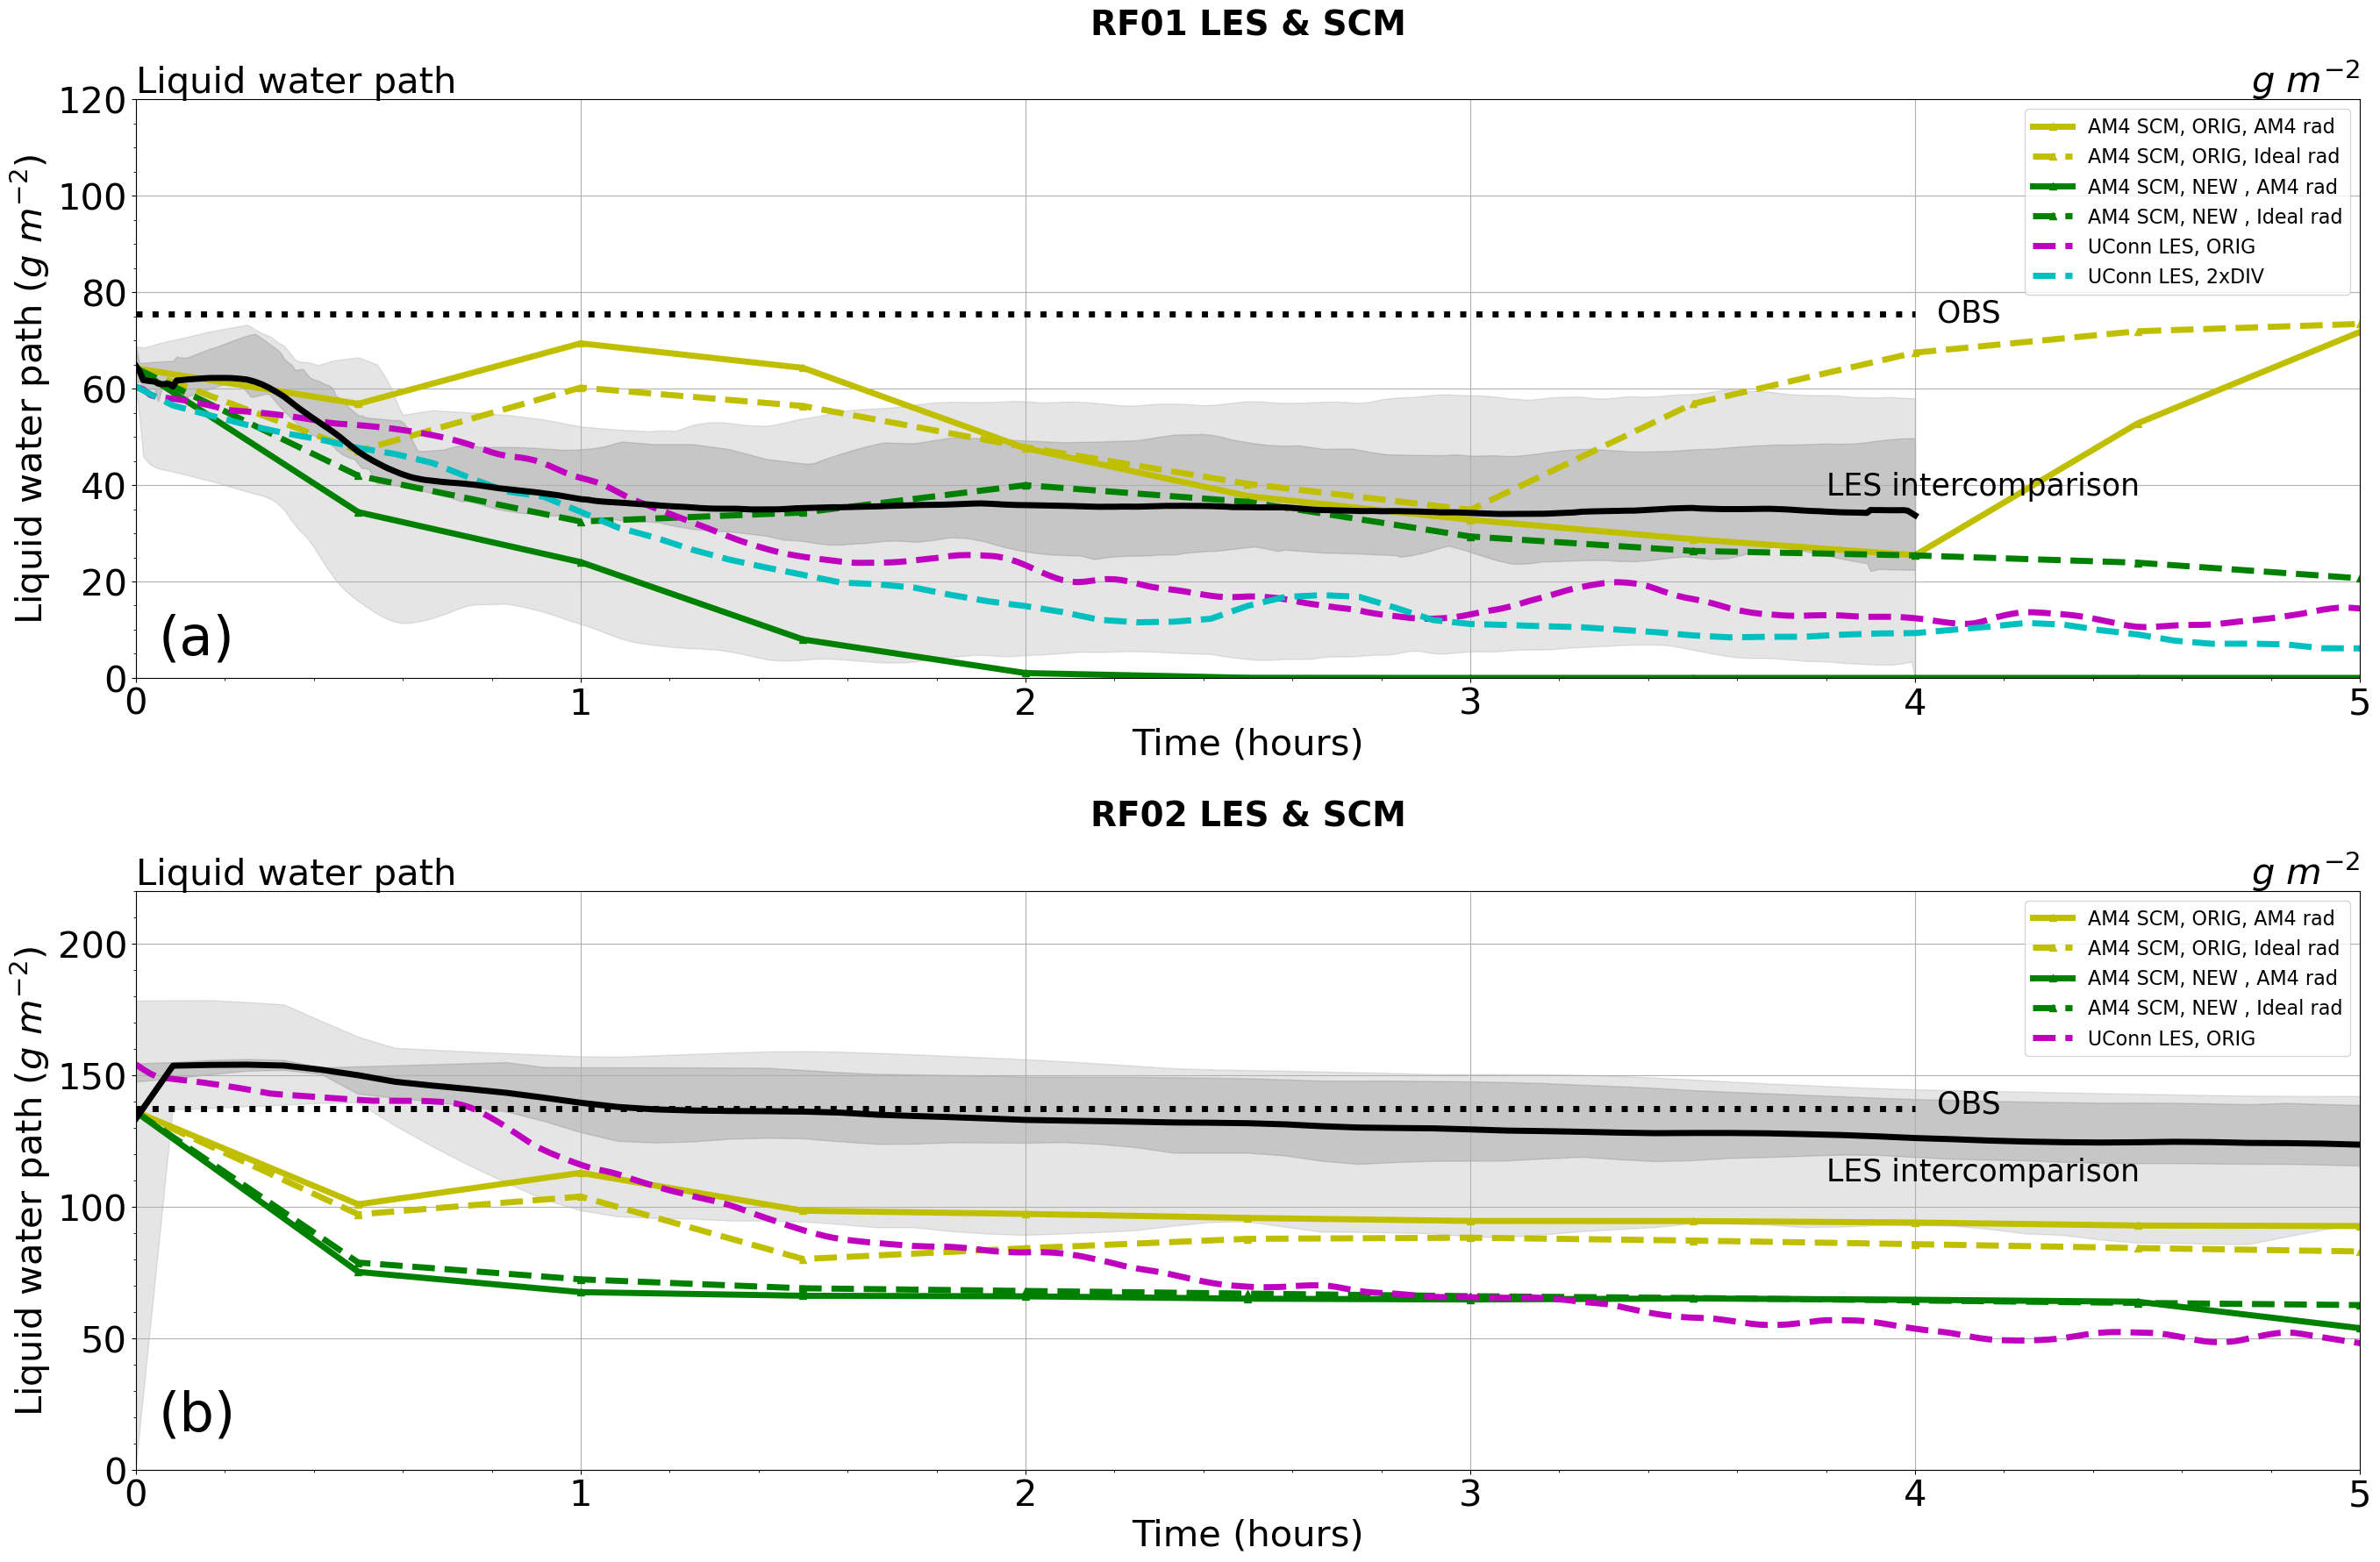

In [32]:
varname = "LWP0"
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(30, 20))
fig.tight_layout(pad=7)

maintitle = "RF01 LES & SCM"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1, fontweight='bold')
                    
plot_scm_time_series(
    das_rf01, 
    time_coord = tt, 
    tt_start = tt_start, tt_end = tt_end, 
    names_styles = names_styles_rf01_02, varname = varname, ax=ax1, var_factor = 1000,
    plot_les = "George_RF01_1x2xDiv", 
)

var_dum = da_rf01_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)
ax1.set_ylim([0,120])

#--- plot LES and OBS
plot_les_obs(ax1, iop = "RF01")

#===================
maintitle = "RF02 LES & SCM"
ax2.set_title(maintitle, loc='center', fontsize = 28, y=1.1, fontweight='bold')
                    
plot_scm_time_series(
    das_rf02, 
    time_coord = tt, 
    tt_start = tt_start, tt_end = tt_end, 
    names_styles = names_styles_rf01_02, varname = varname, ax=ax2, var_factor = 1000,
    plot_les = "George_RF02", 
       )

var_dum = da_rf02_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax2, var_dum)

gm2=r"$g \ m^{-2}$"
fontsize_string = 30
ax2.set_title(gm2, loc='right', fontsize = fontsize_string)
ax1.set_title(gm2, loc='right', fontsize = fontsize_string)

ylabel = r"Liquid water path ($g \ m^{-2}$)"
ax1.set_ylabel(ylabel, fontsize = fontsize_string)
ax2.set_ylabel(ylabel, fontsize = fontsize_string)


#--- plot LES and OBS
plot_les_obs(ax2, iop = "RF02")
ax2.set_ylim([0., 220.])

ax1.text(0.05, 5, "(a)", fontsize = 45)
ax2.text(0.05, 15, "(b)", fontsize = 45)

#### Plot - RF01, Stv IC, 1xDiv & L07+hadv, scmRAD and am4RAD

<xarray.DataArray 'time' (time: 8)>
array([cftime.DatetimeJulian(2001, 7, 10, 8, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 8, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 9, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 9, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 10, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 10, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 11, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 10, 11, 45, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
    lon      float64 237.5
    lat      float64 31.5
  * time     (time) object 2001-07-10 08:15:00 ... 2001-07-10 11:45:00
Attributes:
    long_name:       time
    cartesian_axis:  T
    calendar_type:   JULIAN
    bounds:          time_bnds
Exp [AM4 SCM, std forc, AM4 rad], avg [LWP0] over time step [0, 8]

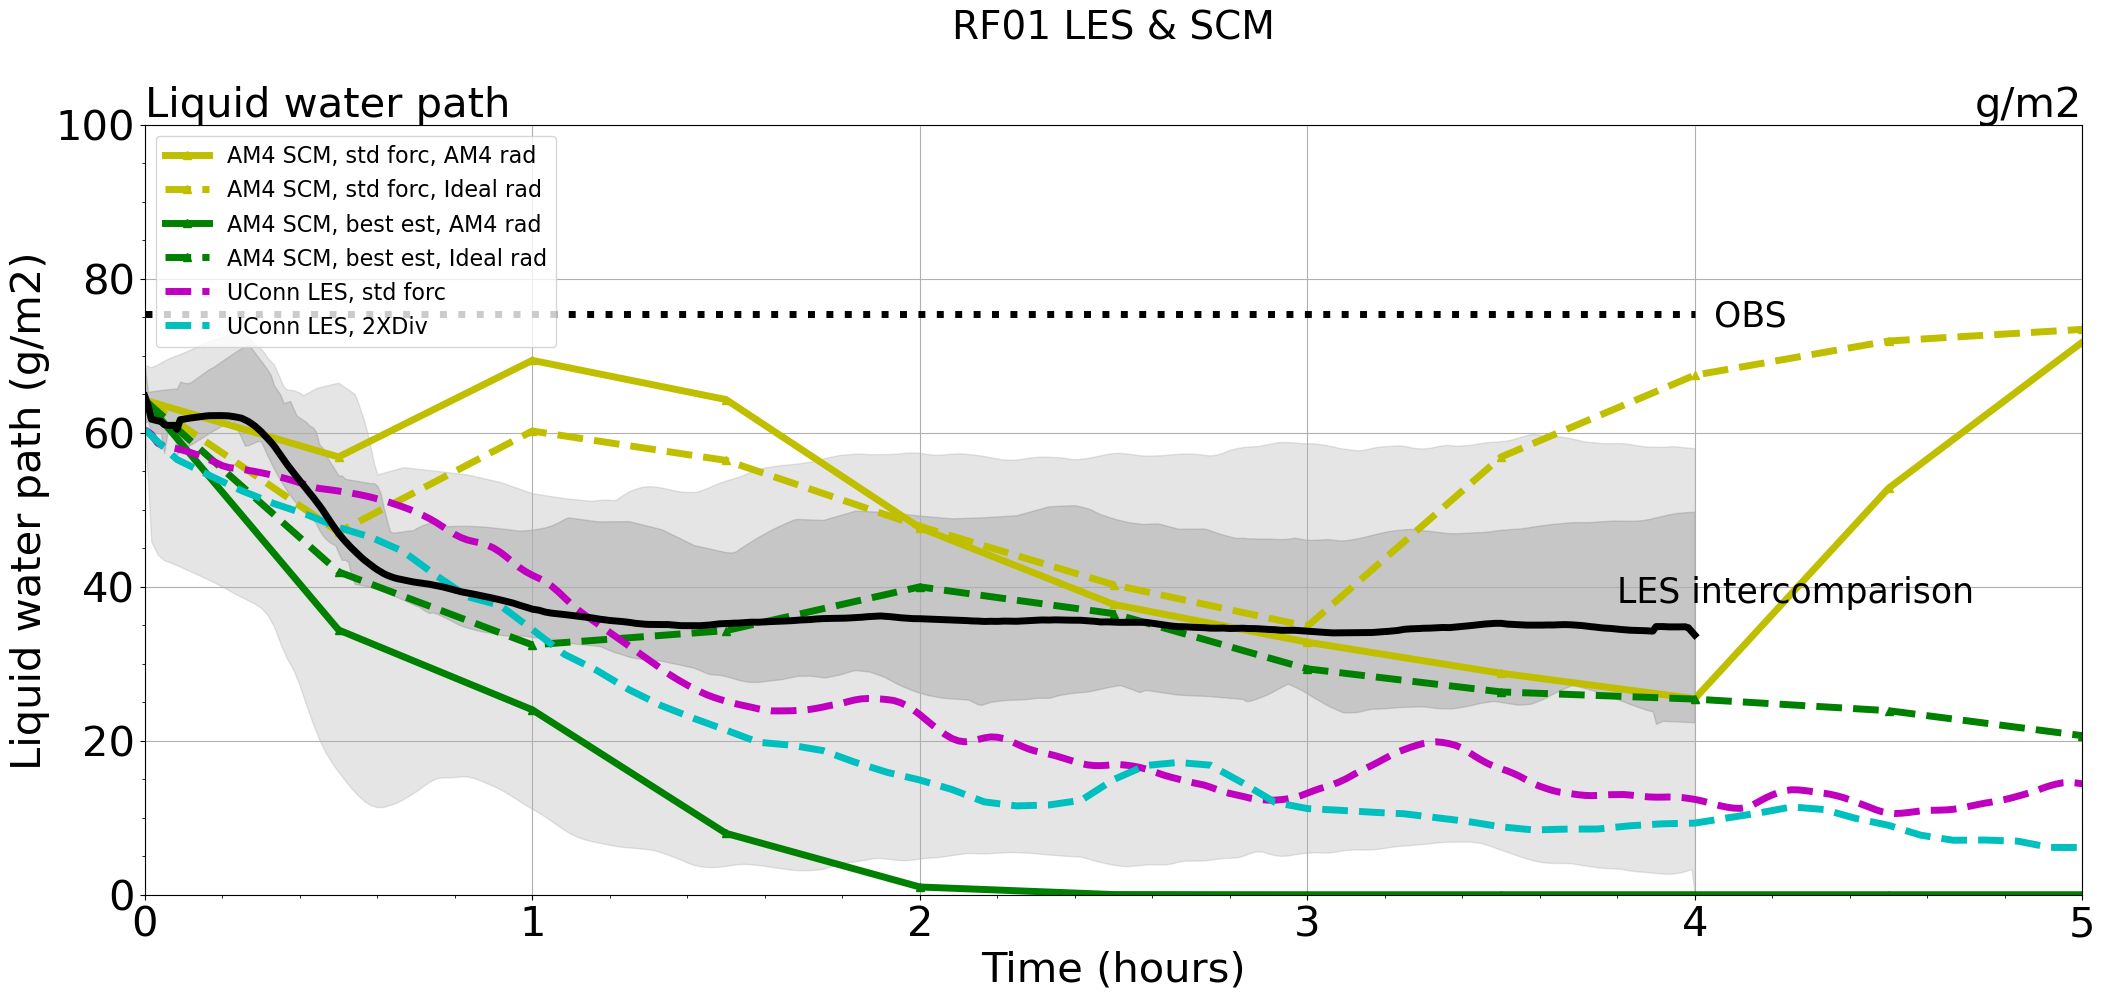

In [23]:
varname = "LWP0"

fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF01 LES & SCM"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)
                    
plot_scm_time_series(
    das_rf01, 
    time_coord = tt, 
    tt_start = tt_start, tt_end = tt_end, 
    names_styles = names_styles_rf01_02, varname = varname, ax=ax1, var_factor = 1000,
    plot_les = "George_RF01_1x2xDiv", 
)

var_dum = da_rf01_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)
ax1.set_ylim([0,100])

#--- plot LES and OBS
plot_les_obs(ax1, iop = "RF01")


#### Plot - RF02, Stv IC, 1xDiv & L07+hadv, scmRAD and am4RAD

<xarray.DataArray 'time' (time: 8)>
array([cftime.DatetimeJulian(2001, 7, 11, 8, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 8, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 9, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 9, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 10, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 10, 45, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 11, 15, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2001, 7, 11, 11, 45, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
    lon      float64 237.5
    lat      float64 31.5
  * time     (time) object 2001-07-11 08:15:00 ... 2001-07-11 11:45:00
Attributes:
    long_name:       time
    cartesian_axis:  T
    calendar_type:   JULIAN
    bounds:          time_bnds
Exp [AM4 SCM, std forc, AM4 rad], avg [LWP0] over time step [0, 8]

(0.0, 200.0)

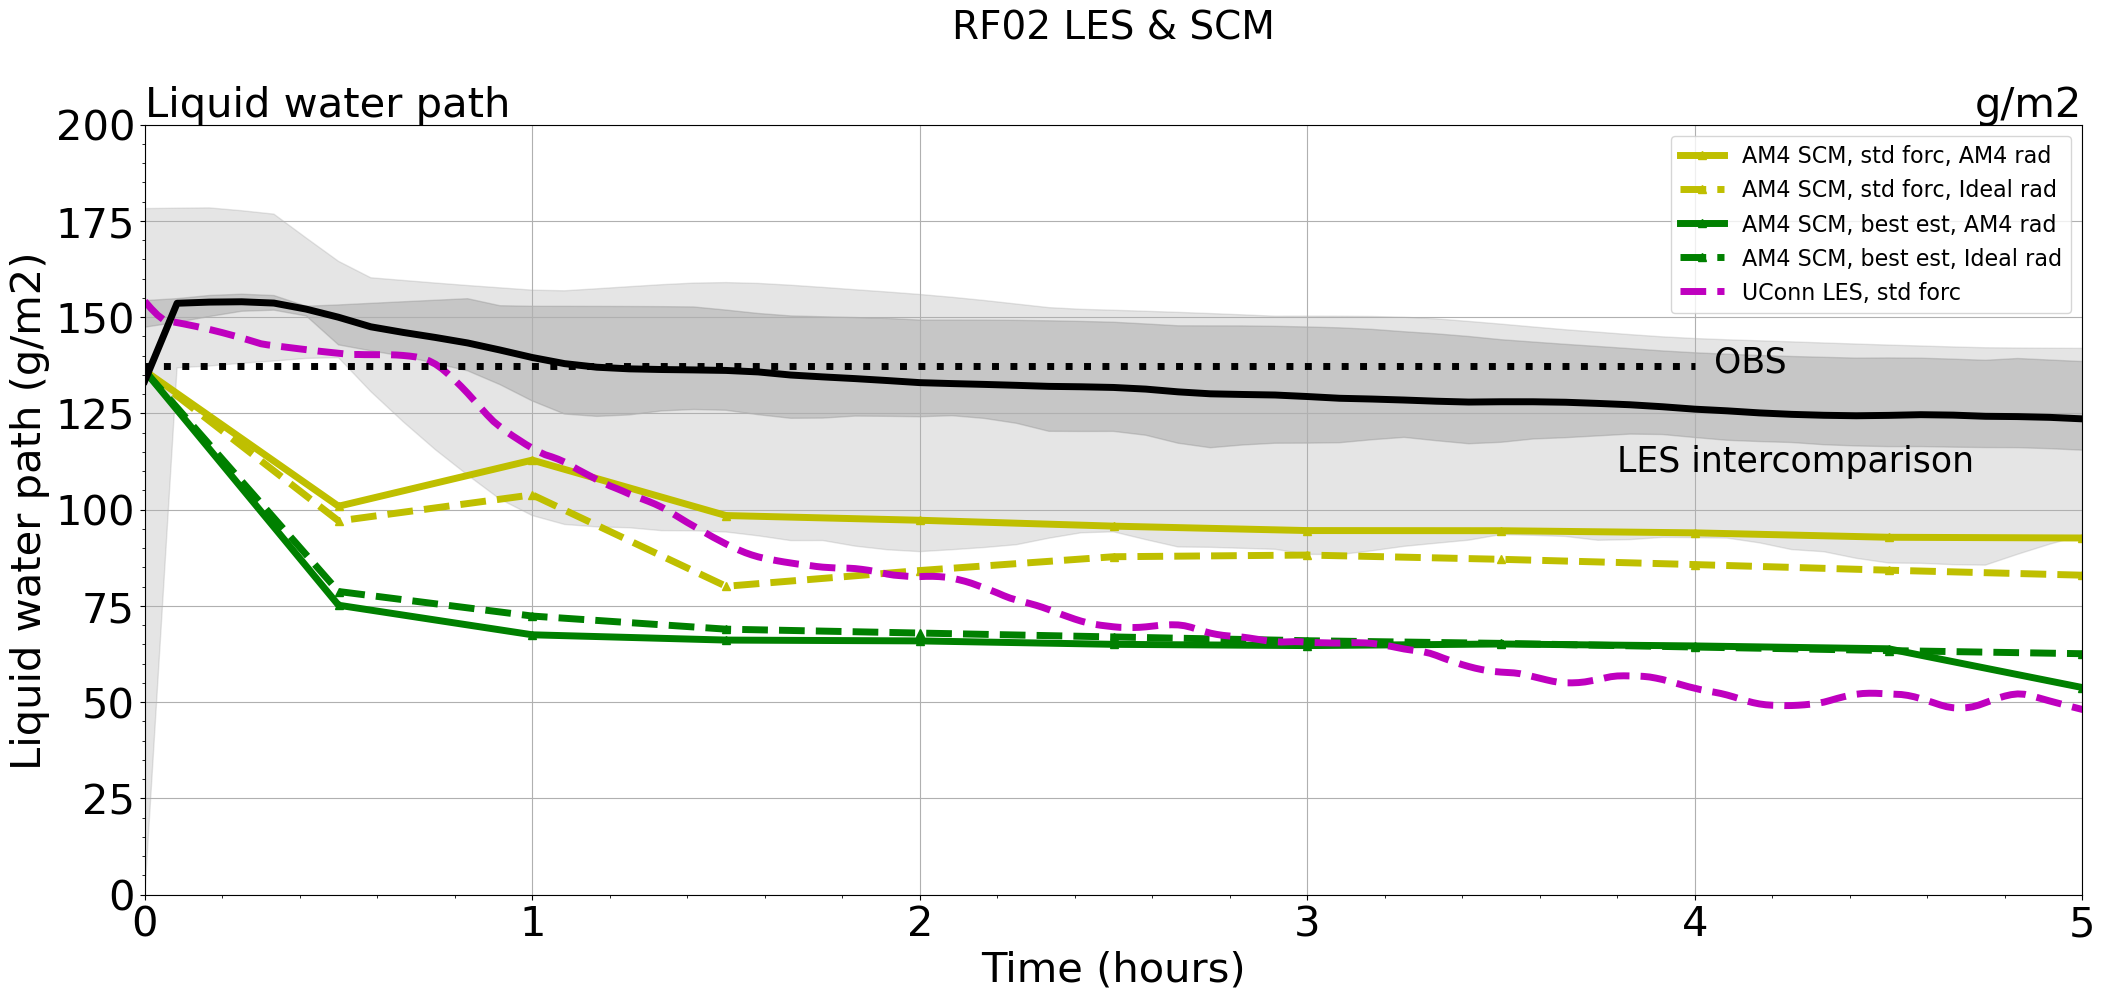

In [24]:
varname = "LWP0"

fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF02 LES & SCM"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)
                    
plot_scm_time_series(
    das_rf02, 
    time_coord = tt, 
    tt_start = tt_start, tt_end = tt_end, 
    names_styles = names_styles_rf01_02, varname = varname, ax=ax1, var_factor = 1000,
    plot_les = "George_RF02", 
       )

var_dum = da_rf02_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)

#--- plot LES and OBS
plot_les_obs(ax1, iop = "RF02")
ax1.set_ylim([0., 200.])


#### Plot - RF01, scmRAD

NameError: name 'datasets_scmRAD_RF01' is not defined

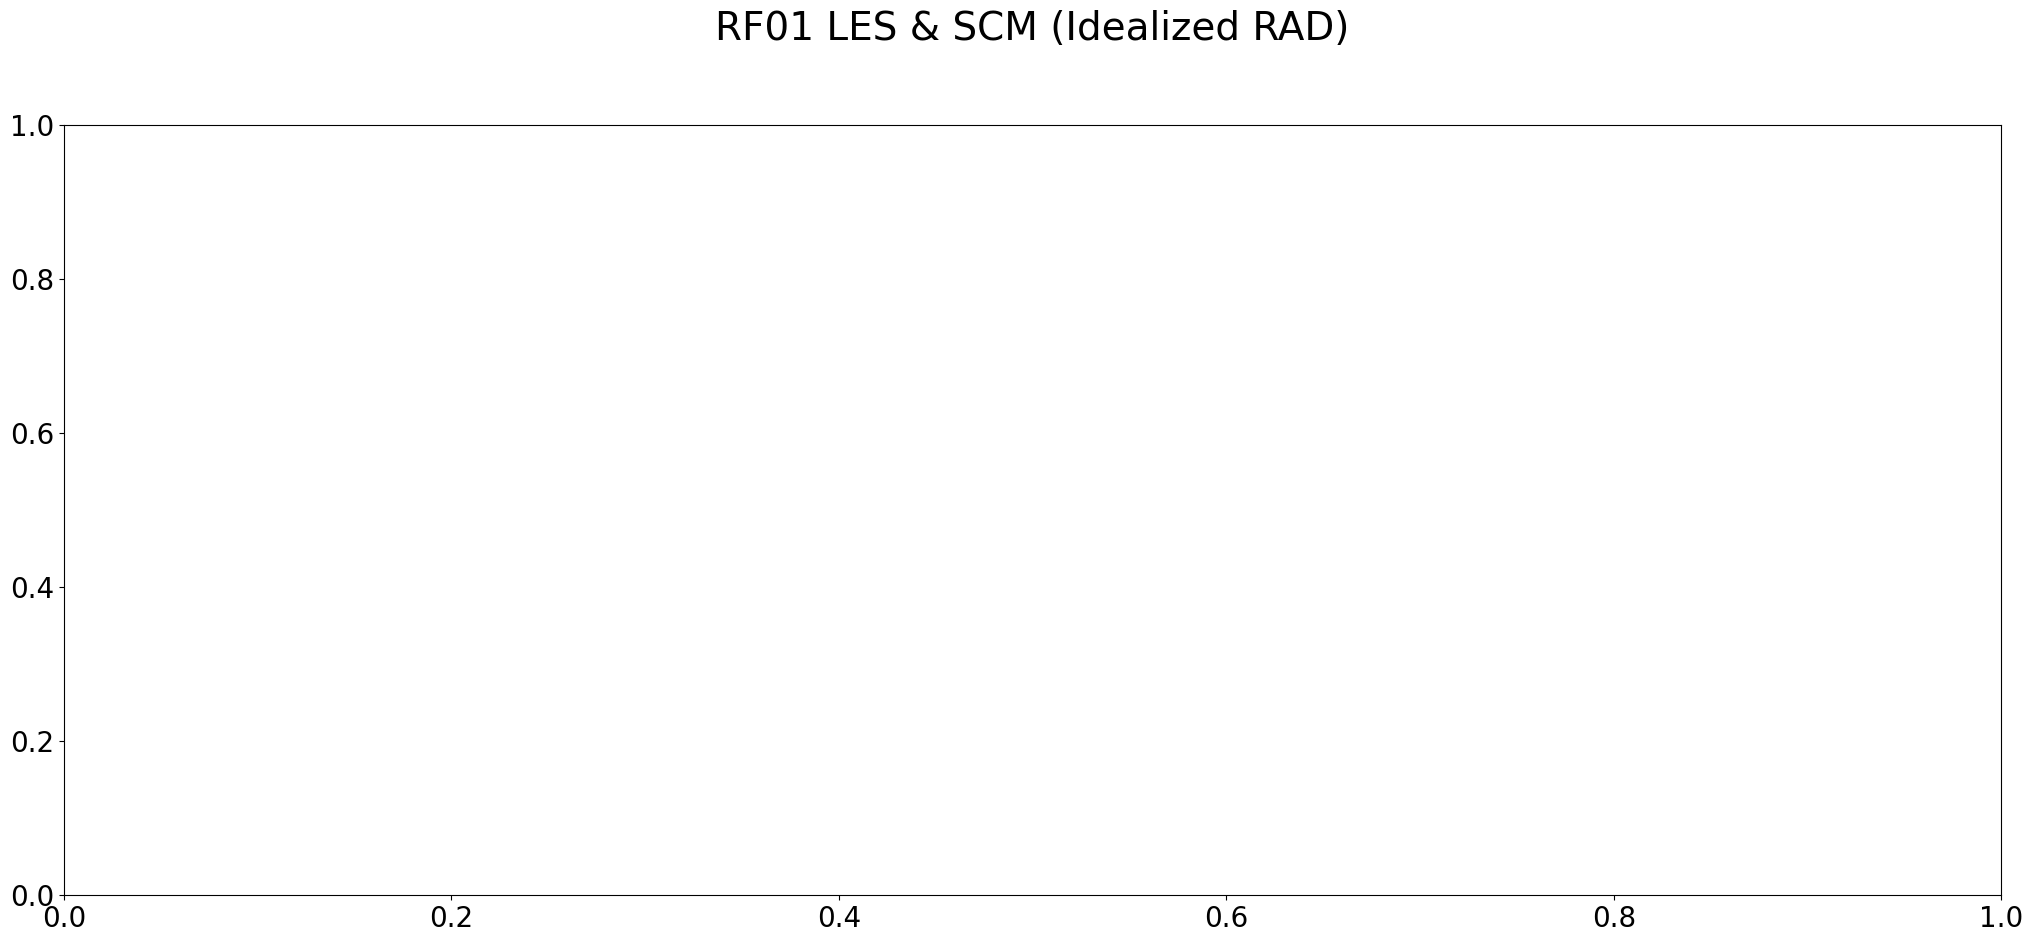

In [25]:
fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF01 LES & SCM (Idealized RAD)"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)
                    
plot_scm_time_series(
    datasets_scmRAD_RF01, 
    time_coord = tt, 
    tt_start = tt_start, tt_end = tt_end, 
    plot_les = "George_RF01",
    names_styles = names_styles_scmRAD, varname = varname, ax=ax1, var_factor = 1000)

var_dum = da_rf01_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)

#--- plot LES and OBS
plot_les_obs(ax1, iop = "RF01")



#### Plot - RF01, am4RAD+sw

NameError: name 'datasets_am4RAD_RF01' is not defined

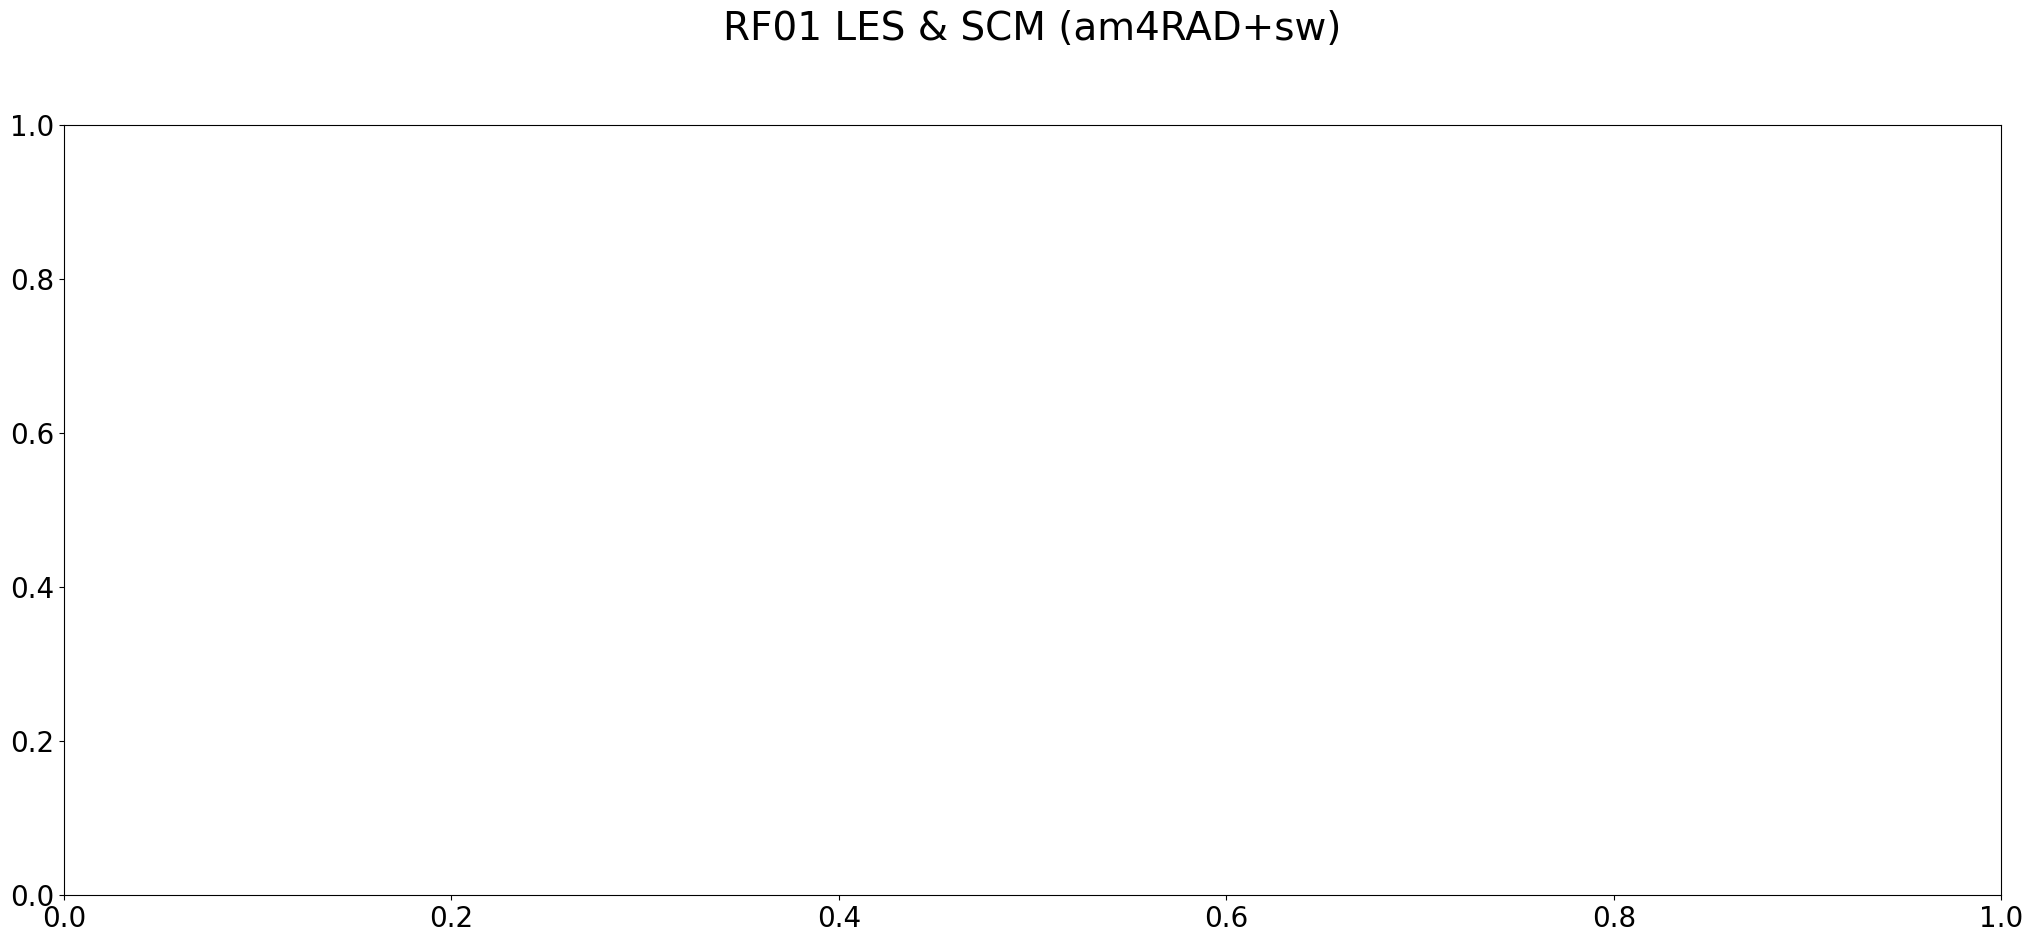

In [26]:
fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF01 LES & SCM (am4RAD+sw)"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)

plot_scm_time_series(
    datasets_am4RAD_RF01,
    time_coord = tt, 
    tt_start = tt_start, tt_end = tt_end, 
    plot_les = "George_RF01",
    names_styles = names_styles_am4RAD, varname = varname, ax=ax1, var_factor = 1000)

var_dum = da_rf01_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)

#--- plot LES and OBS
plot_les_obs(ax1, iop = "RF01", plot_sunrise=True)
  
set_time_ticks(ax1, "RF01")

#### Plot - RF02, scmRAD

NameError: name 'datasets_scmRAD_RF02' is not defined

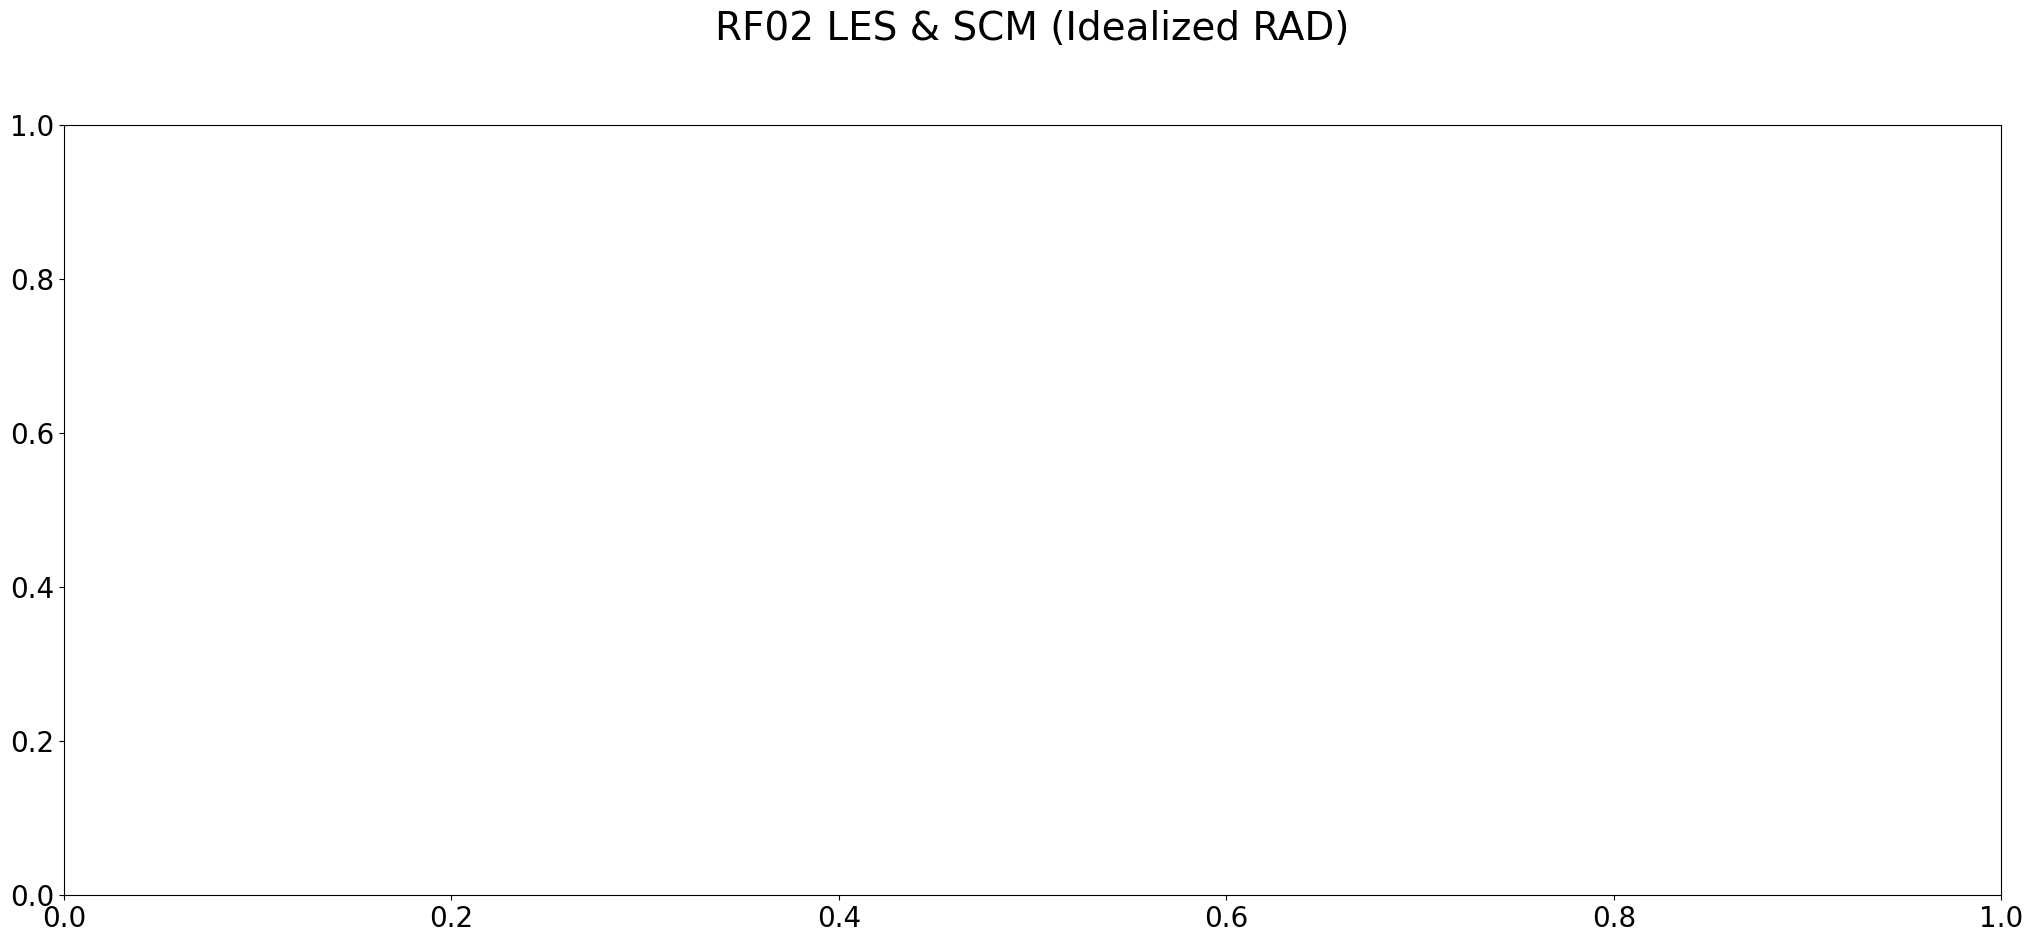

In [27]:
fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF02 LES & SCM (Idealized RAD)"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)
                    
plot_scm_time_series(
    datasets_scmRAD_RF02,  
    time_coord = tt, 
    plot_les = "George_RF02",
    tt_start = tt_start, tt_end = tt_end, 
    names_styles = names_styles_scmRAD, varname = varname, ax=ax1, var_factor = 1000)

var_dum = da_rf02_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)

#--- plot LES and OBS
ax1.set_ylim([0., 200.])

plot_les_obs(ax1, iop = "RF02")


#### Plot - RF02, am4RAD+sw

NameError: name 'datasets_am4RAD_RF02' is not defined

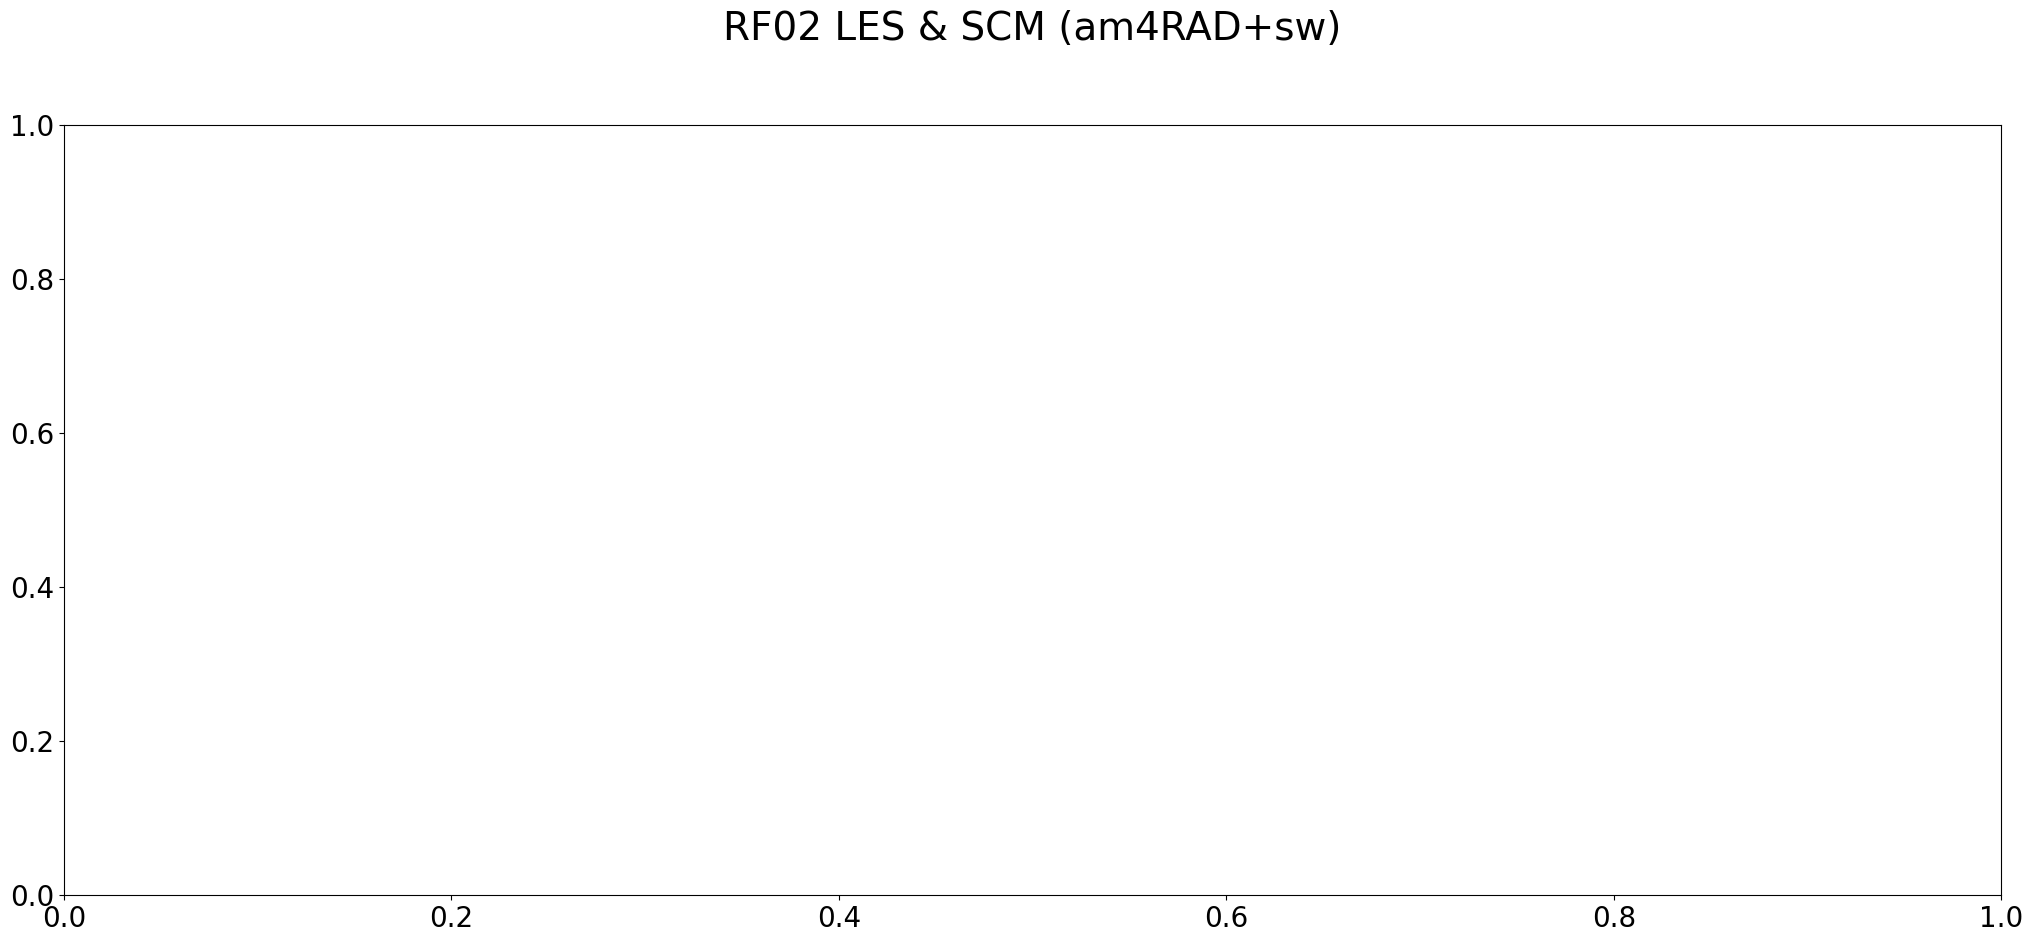

In [28]:
fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF02 LES & SCM (am4RAD+sw)"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)
                    
plot_scm_time_series(
    datasets_am4RAD_RF02, 
    time_coord = tt, 
    plot_les = "George_RF02",
    tt_start = tt_start, tt_end = tt_end, 
    names_styles = names_styles_am4RAD, varname = varname, ax=ax1, var_factor = 1000)

var_dum = da_rf02_scmRAD_ICStv_FStv.get(varname).copy()
var_dum.attrs['long_name']="Liquid water path"
var_dum.attrs['units']="g/m2"
ax_def_xy(ax1, var_dum)

#--- plot LES and OBS
ax1.set_ylim([0., 200.])
plot_les_obs(ax1, iop = "RF02", plot_sunrise=True)

set_time_ticks(ax1, "RF02")

### Do some statistics

#### RF01, George's LES

In [49]:
#--- dataset name
tavg_option = "3_4h"
#tavg_option = "0_4h"

#--- return time average
if (tavg_option == "3_4h"):
    tt1=120  # 3h  for da_les_stv
    tt2=241  # 4h

    #tt1=24   # 3h  for other
    #tt2=49   # 4h

elif (tavg_option == "0_4h"):
    #tt1=0  # 0h  for da_les_stv
    #tt2=241  # 4h

    tt1=0   # 0h  for other
    tt2=49   # 4h

elif (tavg_option == "1st_step"):
    tt_start=0
    tt_end=1

else:
    error_msg = f"ERROR: tavg_option [{tavg_option}] is not supported"
    raise ValueError(error_msg)

varname='lwp'
model = 'LES'

names_styles = {
    "Stv IC, 1xDiv": "r-",
    "Stv IC, 2XDiv": "b-",
    "Stv IC, 4XDiv": "g-",
    "Stv IC, Forc_MERRA": "m--",
    "MERRA IC, Forc_MERRA": "c--",
    }

print(da_les_stv.time[tt1:tt2])
print(da_les_stv_2Xdiv.time[tt1:tt2])

print("")
compute_avg(
    da_les_stv, da_les_stv_2Xdiv, da_les_stv_4Xdiv, da_les_merra3D, da_les_merraIC_F,
    tt1=tt1, tt2=tt2, model = model, 
    names_styles = names_styles, varname = varname, var_factor = 1) 


<xarray.DataArray 'time' (time: 121)>
array([ 7199.8433,  7259.4927,  7319.7163,  7379.6494,  7439.807 ,  7499.4844,
        7559.8936,  7619.6045,  7679.933 ,  7739.654 ,  7799.8906,  7859.9297,
        7919.579 ,  7979.805 ,  8039.8237,  8099.525 ,  8159.597 ,  8219.447 ,
        8279.84  ,  8339.624 ,  8399.656 ,  8459.782 ,  8519.471 ,  8579.409 ,
        8639.584 ,  8699.579 ,  8759.749 ,  8819.702 ,  8879.92  ,  8939.664 ,
        8999.843 ,  9059.51  ,  9119.963 ,  9179.437 ,  9239.403 ,  9299.821 ,
        9359.874 ,  9419.769 ,  9479.967 ,  9539.987 ,  9599.441 ,  9659.56  ,
        9719.916 ,  9779.435 ,  9839.715 ,  9899.922 ,  9959.583 , 10019.627 ,
       10079.5   , 10139.472 , 10199.483 , 10259.978 , 10319.3955, 10379.658 ,
       10439.633 , 10499.619 , 10559.559 , 10619.741 , 10679.685 , 10739.524 ,
       10799.842 , 10859.454 , 10919.397 , 10979.398 , 11039.628 , 11099.94  ,
       11159.849 , 11219.637 , 11279.512 , 11339.607 , 11399.451 , 11459.643 ,
       11519.8

#### RF01, LES intercomparison

In [25]:
#help(yhc.var_stats)

In [26]:
#da_les_comp

In [55]:
dim = "time"
opt = "avg"

#tt1=0  # h  for time step=30s
tt1=240  # 3h  for time step=30s
tt2=481  # 4h

print(da_les_comp.time[tt1:tt2])

stats = yhc.var_stats(da_les_comp.lwp_bar[0,tt1:tt2],  da_les_comp.lwp_bar[2,tt1:tt2], da_les_comp.lwp_bar[3,tt1:tt2], 
                      dim = dim, opt = opt)
print(stats)

<xarray.DataArray 'time' (time: 241)>
array([ 7200.,  7230.,  7260., ..., 14340., 14370., 14400.], dtype=float32)
Coordinates:
  * time     (time) float32 7.2e+03 7.23e+03 7.26e+03 ... 1.437e+04 1.44e+04
Attributes:
    longname:  Time
    units:     [s]
['34.91', '57.93', '4.90']


#### RF02, George's LES

In [60]:
tt1=0  # 0h  for da_les_stv
#tt1=120  # 3h  for da_les_stv
tt2=241  # 4h

varname='lwp'
model = 'LES'

names_styles = {
    "Stv IC, 1xDiv": "r-",
    }

print(da_les_rf02.time[tt1:tt2])
print("")
compute_avg(
    da_les_rf02, 
    tt1=tt1, tt2=tt2, model = model, 
    names_styles = names_styles, varname = varname, var_factor = 1) 

<xarray.DataArray 'time' (time: 241)>
array([    0.      ,    59.98738 ,   119.852135, ..., 14279.93    ,
       14339.896   , 14399.98    ], dtype=float32)
Coordinates:
  * time     (time) float32 0.0 59.99 119.9 ... 1.428e+04 1.434e+04 1.44e+04
Attributes:
    long_name:  time
    units:      s

exp=[Stv IC, 1xDiv], lwp = 91.5, [tt1,tt2]=[0, 241]


#### RF02, LES intercomparison

In [61]:
da_les_comp_rf02.time[0,0,0,23:48]

#lwpavg_les_comp_rf02

<xarray.DataArray 'time' (ntime: 25)>
array([ 7200.,  7500.,  7800.,  8100.,  8400.,  8700.,  9000.,  9300.,  9600.,
        9900., 10200., 10500., 10800., 11100., 11400., 11700., 12000., 12300.,
       12600., 12900., 13200., 13500., 13800., 14100., 14400.], dtype=float32)
Coordinates:
    ntime    int16 ...
Attributes:
    units:     [s]
    longname:  Time

In [64]:
dim = "ntime"
opt = "avg"

tt1=0  # 0h  for time step=5mins
#tt1=23  # 3h  for time step=5mins
tt2=48  # 4h

print(da_les_comp_rf02.time[0,0,0,tt1:tt2])

stats = [
    lwpavg_les_comp_rf02[tt1:tt2].mean("ntime"),
    lwpmin_les_comp_rf02[tt1:tt2].mean("ntime"),
    lwpmax_les_comp_rf02[tt1:tt2].mean("ntime"),
]

#print(lwpavg_les_comp_rf02[tt1:tt2].mean("ntime"))

#stats = yhc.var_stats(lwpavg_les_comp_rf02[tt1:tt2],  lwpmin_les_comp_rf02[tt1:tt2], lwpmax_les_comp_rf02[tt1:tt2], 
#                      dim = dim, opt = opt)
print(stats)

<xarray.DataArray 'time' (ntime: 48)>
array([  300.,   600.,   900.,  1200.,  1500.,  1800.,  2100.,  2400.,  2700.,
        3000.,  3300.,  3600.,  3900.,  4200.,  4500.,  4800.,  5100.,  5400.,
        5700.,  6000.,  6300.,  6600.,  6900.,  7200.,  7500.,  7800.,  8100.,
        8400.,  8700.,  9000.,  9300.,  9600.,  9900., 10200., 10500., 10800.,
       11100., 11400., 11700., 12000., 12300., 12600., 12900., 13200., 13500.,
       13800., 14100., 14400.], dtype=float32)
Coordinates:
    ntime    int16 ...
Attributes:
    units:     [s]
    longname:  Time
[<xarray.DataArray 'lwp' ()>
array(135.88109, dtype=float32)
Attributes:
    units:     [g/m^2]
    longname:  Mean LWP, <xarray.DataArray 'lwp' ()>
array(98.476875, dtype=float32)
Attributes:
    units:     [g/m^2]
    longname:  Mean LWP, <xarray.DataArray 'lwp' ()>
array(156.68965, dtype=float32)
Attributes:
    units:     [g/m^2]
    longname:  Mean LWP]


### Tmp

#### Plot - RF02, tmp

TypeError: plot_scm_time_series() got multiple values for argument 'time_coord'

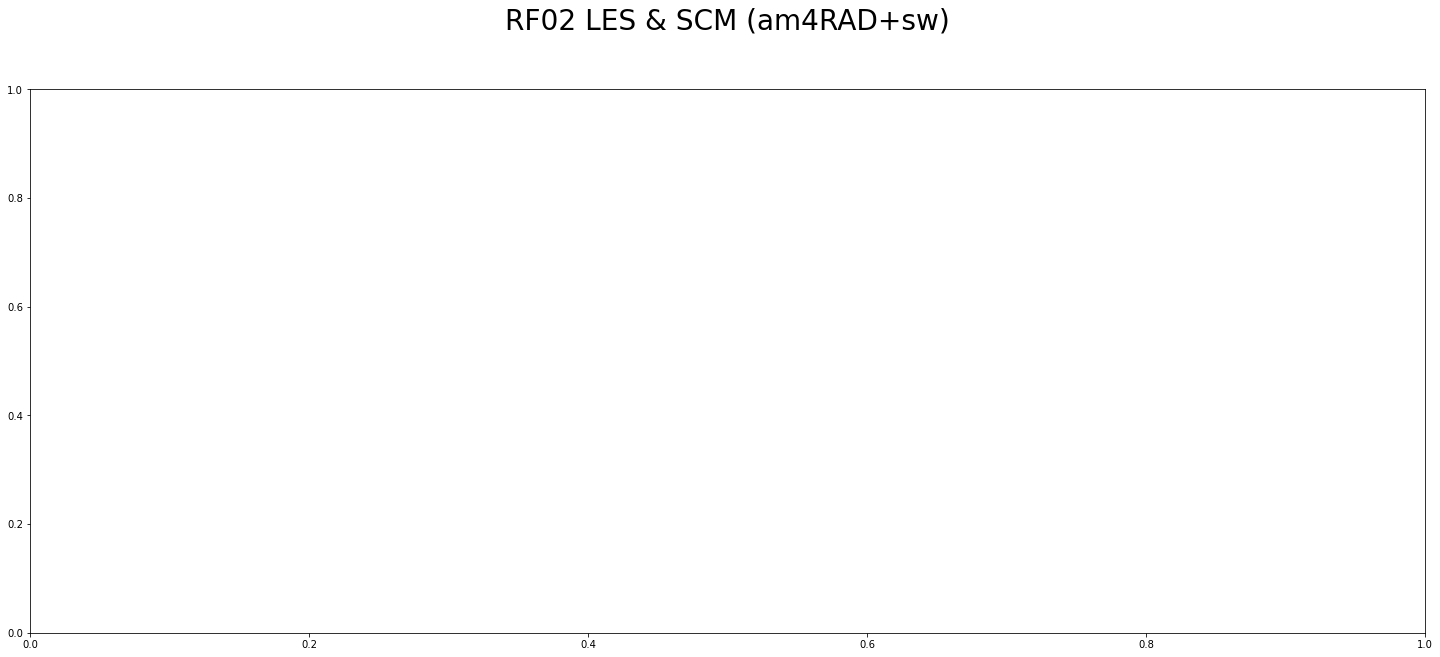

In [31]:
fig, ax1 = plt.subplots(1,1, figsize=(25, 10))
maintitle = "RF02 LES & SCM (am4RAD+sw)"
ax1.set_title(maintitle, loc='center', fontsize = 28, y=1.1)

names_styles = {
    "Stv IC, 1xDiv": "r-",
    "Stv IC, 2XDiv": "b-",
    "Stv IC, 1xDiv+hadv": "g-",
    "Stv IC, Forc_nudge_AM4": "m-",
    "Stv IC, Forc_MERRA": "m--",
    "AM4 IC, Forc_nudge_AM4": "c-",
    "MERRA IC, Forc_MERRA": "c--",
    }
    
varname = "swdn_toa"
                    
plot_scm_time_series(
    da_rf02_am4RAD_ICStv_FStv, da_rf02_am4RAD_ICStv_2Xdiv,  
    da_rf02_am4RAD_ICStv_CGhadv, da_rf02_am4RAD_ICStv_FAM4n, 
    da_rf02_am4RAD_ICStv_FMRA, da_rf02_am4RAD_ICAM4n_FAM4n, 
    da_rf02_am4RAD_ICMRA_FMRA, 
    time_coord = tt, 
    names_styles = names_styles, varname = varname, ax=ax1)

#set_time_ticks(ax1, "RF02")

ax1.set_xlim([tt.min(),12])

## (outdated) Do some statistics

#### Define a function

#### SCM diagnostics

### RF01 LES diagnostics

### SCM diagnostics

### RF01 diagnostics 

### RF02 diagnostics 